### 1. PraPemrosesan Data
Merubah ukuran gambar menjadi 128 * 128

In [1]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, random_split
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F

In [ ]:
DATASET_PATH = './Kuis_Emotion_Classification' 
IMAGE_SIZE = (128, 128)

X_list = []
y_list = []

class_names = ['angry', 'happy', 'sad', 'surprised']
class_mapping = {label: idx for idx, label in enumerate(class_names)}

print("Mulai membaca dan meresize gambar dengan PyTorch...")

for class_name in class_names:
    class_dir = os.path.join(DATASET_PATH, class_name)
    
    if not os.path.exists(class_dir):
        print(f"Folder {class_name} tidak ditemukan, pastikan path sudah benar.")
        continue
        
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        
        if img is not None:
            img_resized = cv2.resize(img, IMAGE_SIZE)
            img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
            
            X_list.append(img_rgb)
            y_list.append(class_mapping[class_name])

X_np = np.array(X_list)
y_np = np.array(y_list)
X_tensor = torch.from_numpy(X_np).permute(0, 3, 1, 2).float()
y_tensor = torch.from_numpy(y_np).long()

print(f"Selesai! Total data: {len(X_tensor)} gambar ")
print(f"Ukuran tensor data X (PyTorch format): {X_tensor.shape}")
print(f"Ukuran tensor label y: {y_tensor.shape}")

Mulai membaca dan meresize gambar dengan PyTorch...
Selesai! Total data: 240 gambar 
Ukuran tensor data X (PyTorch format): torch.Size([240, 3, 128, 128])
Ukuran tensor label y: torch.Size([240])


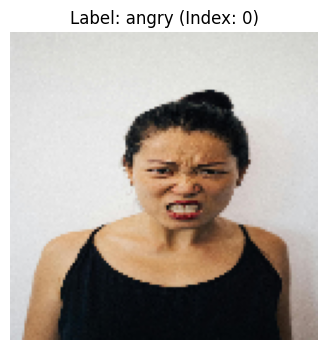

In [ ]:
sample_idx = 0
sample_img = X_tensor[sample_idx]
sample_label = y_tensor[sample_idx].item()
sample_img_flipped = sample_img.permute(1, 2, 0).numpy() / 255.0
plt.figure(figsize=(4, 4))
plt.imshow(sample_img_flipped)
plt.title(f"Label: {class_names[sample_label]} (Index: {sample_label})")
plt.axis('off')
plt.show()

### 2. Data split
Membuat agar data terpisah sesuai banyaknya
Training = 70%
Validation = 15%
Testing = 15%

In [ ]:
dataset = TensorDataset(X_tensor, y_tensor)
total_size = len(dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = int(0.15 * total_size)

torch.manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

print("Pembagian data berhasil dilakukan secara dinamis:")
print(f"Total Dataset          : {total_size} gambar")
print(f"Jumlah data Train (70%): {len(train_dataset)} gambar")
print(f"Jumlah data Val (15%)  : {len(val_dataset)} gambar")
print(f"Jumlah data Test (15%) : {len(test_dataset)} gambar")

assert train_size + val_size + test_size == len(dataset), "Total pembagian data tidak cocok dengan jumlah dataset!"

Pembagian data berhasil dilakukan secara dinamis:
Total Dataset          : 240 gambar
Jumlah data Train (70%): 168 gambar
Jumlah data Val (15%)  : 36 gambar
Jumlah data Test (15%) : 36 gambar


### 3. Data Augmentation
Melakukan normalisasi step 0-1, saya menggunakan zoom, width shift, height shift dan rotation 

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        img, label = self.subset[index]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label
        
    def __len__(self):
        return len(self.subset)

train_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1)
    ),
    transforms.RandomResizedCrop(
        size=(128, 128), 
        scale=(0.8, 1.0), 
        ratio=(1.0, 1.0)                    
    )
])

val_test_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)
])

train_dataset_augmented = EmotionDataset(train_dataset, transform=train_transforms)
val_dataset_normalized = EmotionDataset(val_dataset, transform=val_test_transforms)
test_dataset_normalized = EmotionDataset(test_dataset, transform=val_test_transforms)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset_augmented, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset_normalized, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset_normalized, batch_size=BATCH_SIZE, shuffle=False)

print("Data Augmentation dan Normalisasi berhasil disiapkan!")
print(f"Banyaknya batch pada Train Loader: {len(train_loader)} (Total: {len(train_dataset_augmented)} gambar)")
print(f"Banyaknya batch pada Val Loader  : {len(val_loader)} (Total: {len(val_dataset_normalized)} gambar)")

Data Augmentation dan Normalisasi berhasil disiapkan!
Banyaknya batch pada Train Loader: 11 (Total: 168 gambar)
Banyaknya batch pada Val Loader  : 3 (Total: 36 gambar)


### 4. Arsitektur CNN
Sesuai dengan soal menggunakan struktur 
1. Conv2D
2. MaxPooling
3. Conv2D
4. MaxPooling
5. Flatten
6. Dense
7. Output


In [ ]:
class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dense = nn.Linear(64 * 32 * 32, 128)
        self.relu3 = nn.ReLU()
        self.output = nn.Linear(128, 4)

    def forward(self, x):
        
        x = self.relu1(self.conv1(x))    
        x = self.pool1(x)                
        
        x = self.relu2(self.conv2(x))    
        x = self.pool2(x)                
        
        x = x.view(x.size(0), -1)        
        
        x = self.relu3(self.dense(x))    
        x = self.output(x)               
        
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(device)

print(model)
print(f"\nModel CNN berhasil diinisialisasi pada device: {device}")

EmotionCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dense): Linear(in_features=65536, out_features=128, bias=True)
  (relu3): ReLU()
  (output): Linear(in_features=128, out_features=4, bias=True)
)

Model CNN berhasil diinisialisasi pada device: cuda


### 5. Training
Saya menggunakan 
- Optimizer: Adam
- LossFunction : CrossEntropyLo(categorical_crossentropy)
- Epoch: 25

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

epochs = 25

print("Mulai proses Training...")
print("-" * 50)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

print("-" * 50)
print("Training Selesai!")

Mulai proses Training...
--------------------------------------------------
Epoch [1/25] -> Train Loss: 1.5745 | Train Acc: 30.95% | Val Loss: 1.3596 | Val Acc: 27.78%
Epoch [2/25] -> Train Loss: 1.3417 | Train Acc: 35.71% | Val Loss: 1.1447 | Val Acc: 52.78%
Epoch [3/25] -> Train Loss: 1.2419 | Train Acc: 35.71% | Val Loss: 1.3278 | Val Acc: 38.89%
Epoch [4/25] -> Train Loss: 1.2160 | Train Acc: 44.05% | Val Loss: 1.1263 | Val Acc: 52.78%
Epoch [5/25] -> Train Loss: 1.2004 | Train Acc: 44.05% | Val Loss: 1.1251 | Val Acc: 50.00%
Epoch [6/25] -> Train Loss: 1.1632 | Train Acc: 48.21% | Val Loss: 1.4212 | Val Acc: 41.67%
Epoch [7/25] -> Train Loss: 1.1406 | Train Acc: 50.00% | Val Loss: 1.1740 | Val Acc: 41.67%
Epoch [8/25] -> Train Loss: 1.1574 | Train Acc: 45.83% | Val Loss: 1.1611 | Val Acc: 47.22%
Epoch [9/25] -> Train Loss: 1.0569 | Train Acc: 57.74% | Val Loss: 1.0644 | Val Acc: 63.89%
Epoch [10/25] -> Train Loss: 0.9688 | Train Acc: 58.93% | Val Loss: 1.2308 | Val Acc: 52.78%
Epo

### 6. Evaluasi
pada bagian ini saya hanya menampilkan dalam bentuk teks, plot, confussion matrix dan hasil testnya

--- Akurasi Akhir ---
Final Training Accuracy   : 76.19%
Final Validation Accuracy : 52.78%



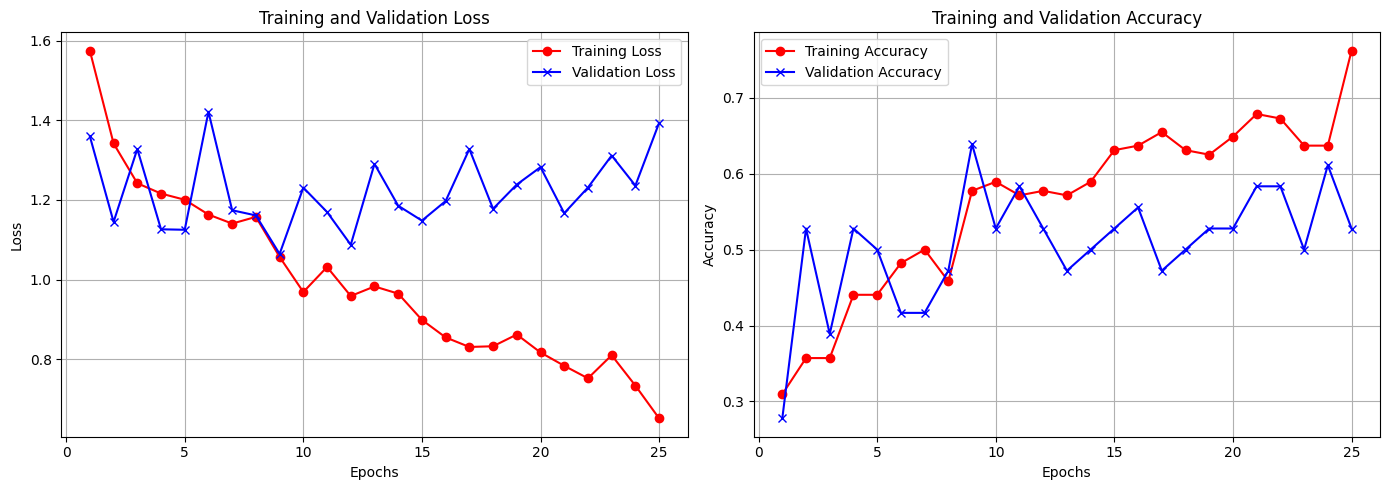

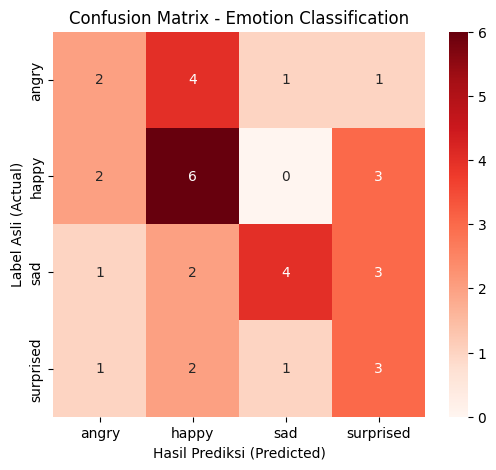


--- Visualisasi Prediksi 36 Gambar Test ---


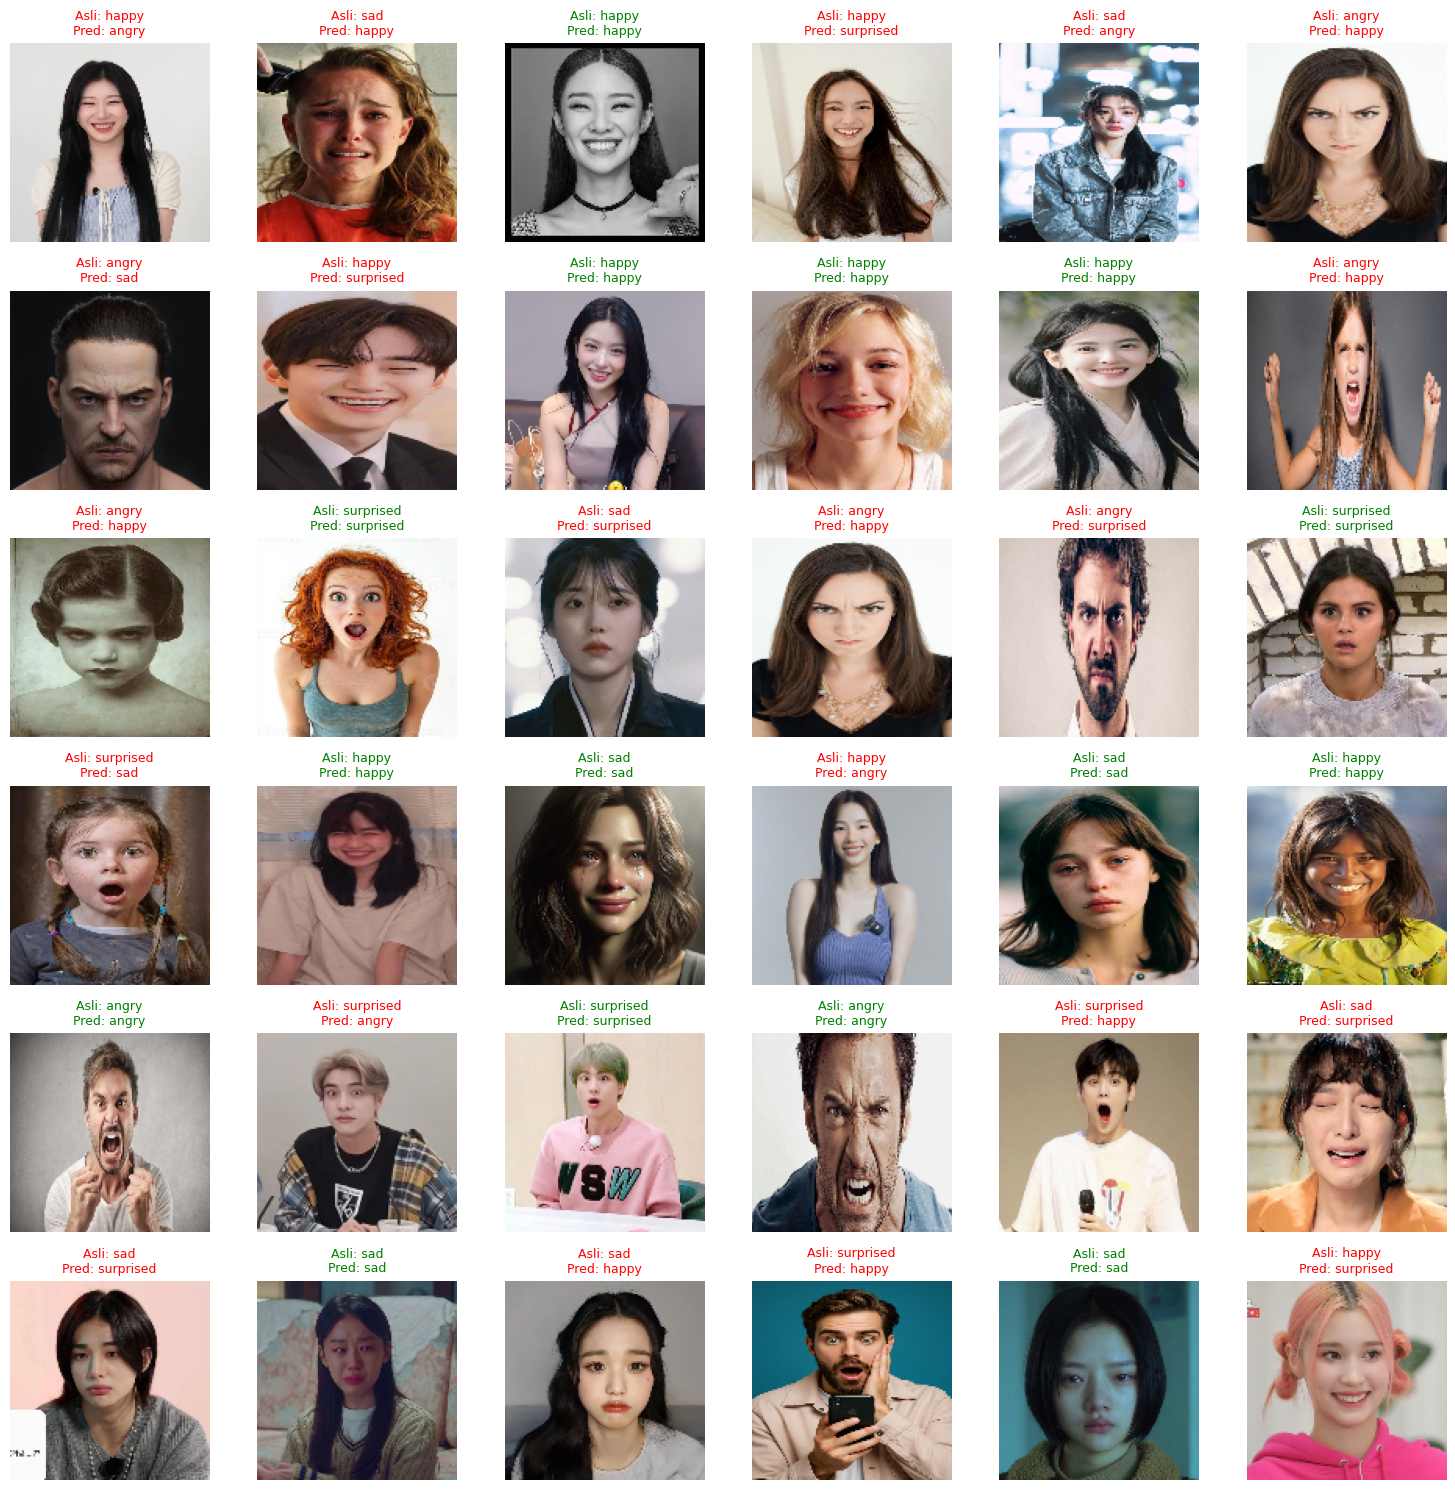

In [9]:
# =====================================================================
# 1. TAMPILKAN AKURASI AKHIR TRAINING DAN VALIDATION
# =====================================================================
print("--- Akurasi Akhir ---")
print(f"Final Training Accuracy   : {history['train_acc'][-1]*100:.2f}%")
print(f"Final Validation Accuracy : {history['val_acc'][-1]*100:.2f}%\n")


# =====================================================================
# 2. GRAFIK TRAINING & VALIDATION (ACCURACY & LOSS)
# =====================================================================
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Grafik Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', color='red', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='blue', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# =====================================================================
# 3. EVALUASI DATA TEST & CONFUSION MATRIX
# =====================================================================
model.eval()
all_preds = []
all_labels = []
all_imgs = []

# Ambil semua data dari test_loader untuk dievaluasi
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_imgs.extend(images.numpy()) # Simpan gambar format tensor asal (C, H, W) untuk plot nanti

# Buat Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Emotion Classification')
plt.ylabel('Label Asli (Actual)')
plt.xlabel('Hasil Prediksi (Predicted)')
plt.show()


# =====================================================================
# 4. PREDIKSI SEMUA GAMBAR TEST (36 GAMBAR)
# =====================================================================
print("\n--- Visualisasi Prediksi 36 Gambar Test ---")
plt.figure(figsize=(15, 15))

# Lakukan perulangan untuk menampilkan ke-36 gambar test
for i in range(len(all_imgs)):
    plt.subplot(6, 6, i + 1) # Matriks grid gambar 6x6 = 36 gambar
    
    # Kembalikan dimensi dari (C, H, W) ke (H, W, C) untuk matplotlib
    img_to_show = all_imgs[i].transpose(1, 2, 0)
    
    # Ambil label teks
    true_label_name = class_names[all_labels[i]]
    pred_label_name = class_names[all_preds[i]]
    
    # Tampilkan gambar
    plt.imshow(img_to_show)
    
    # Beri warna hijau jika tebakan benar, merah jika salah
    title_color = 'green' if all_preds[i] == all_labels[i] else 'red'
    
    plt.title(f"Asli: {true_label_name}\nPred: {pred_label_name}", color=title_color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 7. **Analisis Hasil Model CNN Emotion Classification**

#### **A. Indikasi Overfitting atau Underfitting**
Berdasarkan grafik *accuracy* dan *loss* yang dihasilkan, model ini menunjukkan indikasi **Overfitting** yang cukup kuat:
* **Dari Grafik Loss:** Terlihat jelas bahwa *Training Loss* (garis merah) terus menurun secara konsisten hingga mendekati angka 0.6. Namun, *Validation Loss* (garis biru) cenderung stagnan, tidak stabil, bahkan mulai merangkak naik kembali setelah epoch ke-10 menuju angka 1.4.
* **Dari Grafik Accuracy:** Nilai *Training Accuracy* terus meningkat hingga menembus kisaran 76%, sedangkan *Validation Accuracy* mengalami fluktuasi yang drastis dan tertinggal di 52%. Hal ini menunjukkan model menghafal data *training* tetapi gagal melakukan generalisasi pada data baru.

---

#### **B. Analisis Kelas Emosi Berdasarkan Confusion Matrix**
Berdasarkan visualisasi *Confusion Matrix*, model mengalami bias tinggi ke arah kelas *Happy* sehingga sering menyerap kesalahan prediksi dari kelas lain. Dampak terburuknya terlihat pada kelas *Angry* dan *Surprised* yang performanya paling rendah; model hanya mampu menebak masing-masing 2 dan 3 gambar dengan benar, di mana kelas *Angry* paling sering keliru diklasifikasikan sebagai *Happy* (4 kali), sementara sisa sampel *Surprised* tersebar salah diprediksi sebagai *Happy* (2 kali), *Angry* (1 kali), dan *Sad* (1 kali).

---

#### **C. Faktor Penyebab Kesalahan Klasifikasi dan Solusinya**

* **Faktor Penyebab:**
  1. **Keterbatasan Jumlah Dataset:** Total data yang hanya 240 gambar (60 gambar per kelas) sangatlah sedikit untuk melatih arsitektur deep learning dari awal (*from scratch*). Model kekurangan variasi sampel untuk mempelajari fitur esensial wajah.
  2. **Karakteristik Ekspresi Wajah yang Ambigu:** Kemiripan bentuk kerutan wajah antar-emosi (misalnya, mulut terbuka pada ekspresi *Happy* bisa menyerupai ekspresi *Surprised*, atau kerutan dahi *Sad* menyerupai *Angry*) membuat model sederhana ini bingung.
  3. **Arsitektur Model Terlalu Sederhana:** Arsitektur minimum yang digunakan belum memiliki regulasi yang kuat untuk menahan laju *overfitting* pada data kecil.

* **Cara Mengatasi / Solusi:**
  1. **Menambahkan Regulasi (Dropout & Batch Normalization):** Menyisipkan layer `nn.Dropout(0.5)` setelah *fully connected layer* untuk memutus saraf tiruan secara acak saat *training*, sehingga model tidak menghafal data.
  2. **Menggunakan Transfer Learning (Pre-trained Model):** Dibanding melatih model dari nol, sebaiknya gunakan arsitektur yang sudah terlatih dengan jutaan gambar seperti *MobileNetV3*, *ResNet*, atau *VGG* yang kemudian di-*fine-tuning* pada dataset emosi ini.
  3. **Memperluas Data Augmentation:** Menambahkan teknik augmentasi yang lebih agresif atau menggunakan teknik *Synthetic Data Generation* untuk memperbanyak variasi gambar secara artifisial.